In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

### Logistic regression

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8419


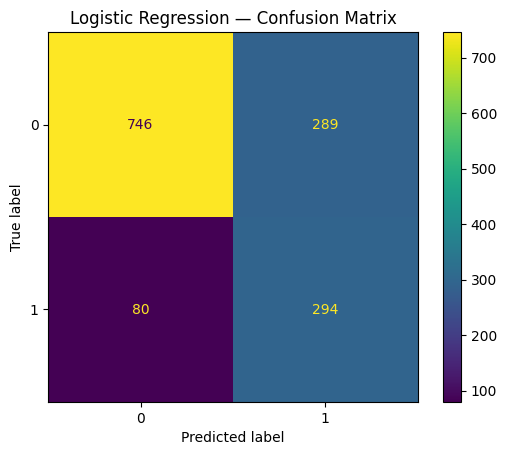

In [3]:
# Train
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

- High false positive due to class_weight='balanced', the model is agressive about spotting churn
- AUC score is more reliable due to an imbalanced data set
- Overall a solid baseline model

### Random Forest

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8206


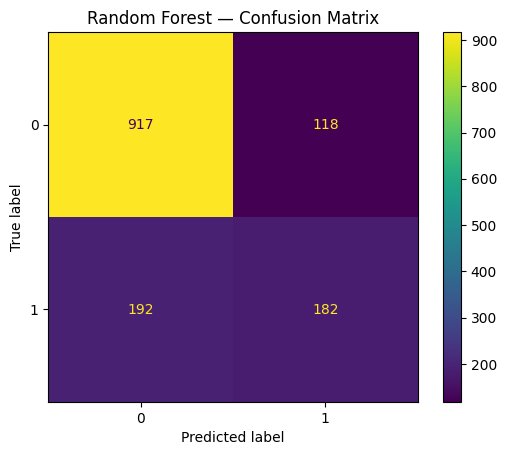

In [4]:
# Train
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # uses all CPU cores to train faster
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest — Confusion Matrix')
plt.show()

Logistic Regression with class_weight='balanced' aggressively overcompensates for the 27/73 imbalance, it lowers its decision threshold, casting a wide net to catch churners. It would rather flag 10 false alarms than miss one real churner. High recall, messy precision.

Random Forest with class_weight='balanced' handles imbalance differently. Each tree votes independently, and the majority vote naturally skews conservative, the forest needs reasonable consensus across trees before predicting churn. Stricter, fewer false alarms, but misses more real churners.

### XGBoost

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC: 0.8197


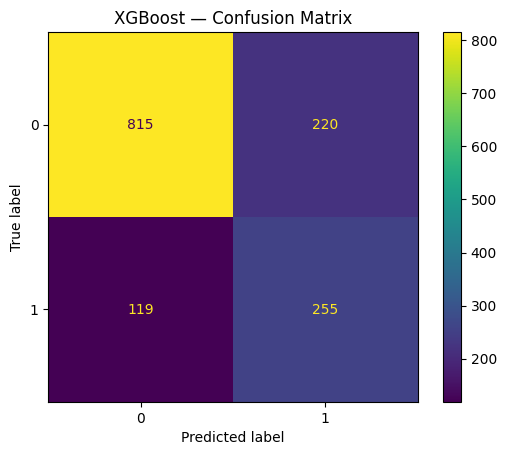

In [8]:

# Train
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title('XGBoost — Confusion Matrix')
plt.show()

The Initial Model actually performs worse than Random Forest and Logistic Regression in terms of the ROC-AUC score
We will tweak hyper parameter using a GridSearchCV 

In [ ]:
# Define the Grid 
param_grid = {
    'max_depth': [3, 4, 5],             # How deep the trees can grow
    'learning_rate': [0.01, 0.05, 0.1], # How fast the model learns
    'n_estimators': [100, 300]          # How many trees to build
}


# Base Model
xgb_base = XGBClassifier(
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

# Configure GridSearchCV with AUC as the score not Accuracy to assess the model
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    cv=5, 
    verbose=1,      # Prints progress updates
    n_jobs=-1       # Uses all the computer's cores to speed it up
)

# Search
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# The Reveal
print("\n--- Grid Search Results ---")
print(f"Best ROC-AUC Score: {grid_search.best_score_:.4f}")
print("Best Parameters:", grid_search.best_params_)

# Use the Best Model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)


print(classification_report(y_test, y_pred_best))




Starting Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- Grid Search Results ---
Best ROC-AUC Score: 0.8470
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



[]

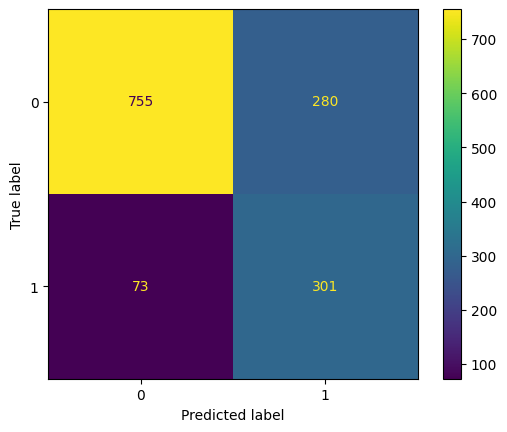

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.plot()